In [1]:
import warnings     #to supress the warnings
warnings.filterwarnings('ignore')

import numpy as np         #importing numpy and pandas
import pandas as pd

import matplotlib.pyplot as plt    #to visualise the code by graph
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from collections import Counter
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,roc_curve,classification_report
import seaborn as sns
%matplotlib inline

# Read an explore the data

In [10]:
data = pd.read_csv("engine_data.csv")              #reading the data
data.head(10)                                    #shows the first 10 rows of the data

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine Condition
0,700,2.493592,11.790927,3.178981,84.144163,81.632187,1
1,876,2.941606,16.193866,2.464504,77.640934,82.445724,0
2,520,2.961746,6.553147,1.064347,77.752266,79.645777,1
3,473,3.707835,19.510172,3.727455,74.129907,71.774629,1
4,619,5.672919,15.738871,2.052251,78.396989,87.000225,0
5,1221,3.989226,6.679231,2.214250,76.401152,75.669818,0
6,716,3.568896,5.312266,2.461067,83.646589,79.792411,1
7,729,3.845166,10.191126,2.362998,77.921202,71.671761,1
8,845,4.877239,3.638269,3.525604,76.301626,70.496024,0
9,824,3.741228,7.626214,1.301032,77.066520,85.143297,0


In [ ]:
data.info()      #gives info of the deta

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19535 entries, 0 to 19534
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Engine rpm        19535 non-null  int64  
 1   Lub oil pressure  19535 non-null  float64
 2   Fuel pressure     19535 non-null  float64
 3   Coolant pressure  19535 non-null  float64
 4   lub oil temp      19535 non-null  float64
 5   Coolant temp      19535 non-null  float64
 6   Engine Condition  19535 non-null  int64  
dtypes: float64(5), int64(2)
memory usage: 1.0 MB


In [ ]:
data.describe()   #gives the statistical summary of the data

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine Condition
count,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000
mean,791.239263,3.303775,6.655615,2.335369,77.643420,78.427433,0.630509
std,267.611193,1.021643,2.761021,1.036382,3.110984,6.206749,0.482679
min,61.000000,0.003384,0.003187,0.002483,71.321974,61.673325,0.000000
25%,593.000000,2.518815,4.916886,1.600466,75.725990,73.895421,0.000000
50%,746.000000,3.162035,6.201720,2.166883,76.817350,78.346662,1.000000
75%,934.000000,4.055272,7.744973,2.848840,78.071691,82.915411,1.000000
max,2239.000000,7.265566,21.138326,7.478505,89.580796,195.527912,1.000000


In [ ]:
missing_values = data.isnull().sum()   #checks for null values
missing_values

Engine rpm          0
Lub oil pressure    0
Fuel pressure       0
Coolant pressure    0
lub oil temp        0
Coolant temp        0
Engine Condition    0
dtype: int64

In [ ]:
duplicate_rows = data.duplicated().sum()                    #this line checks for duplicate rows
print('Duplicate rows: ',duplicate_rows)

data = data.drop_duplicates()                               # this drops duplicate rows

Duplicate rows:  0


In [ ]:
data.columns    #shows all columns

Index(['Engine rpm', 'Lub oil pressure', 'Fuel pressure', 'Coolant pressure',
       'lub oil temp', 'Coolant temp', 'Engine Condition'],
      dtype='object')

#Data Visualizations

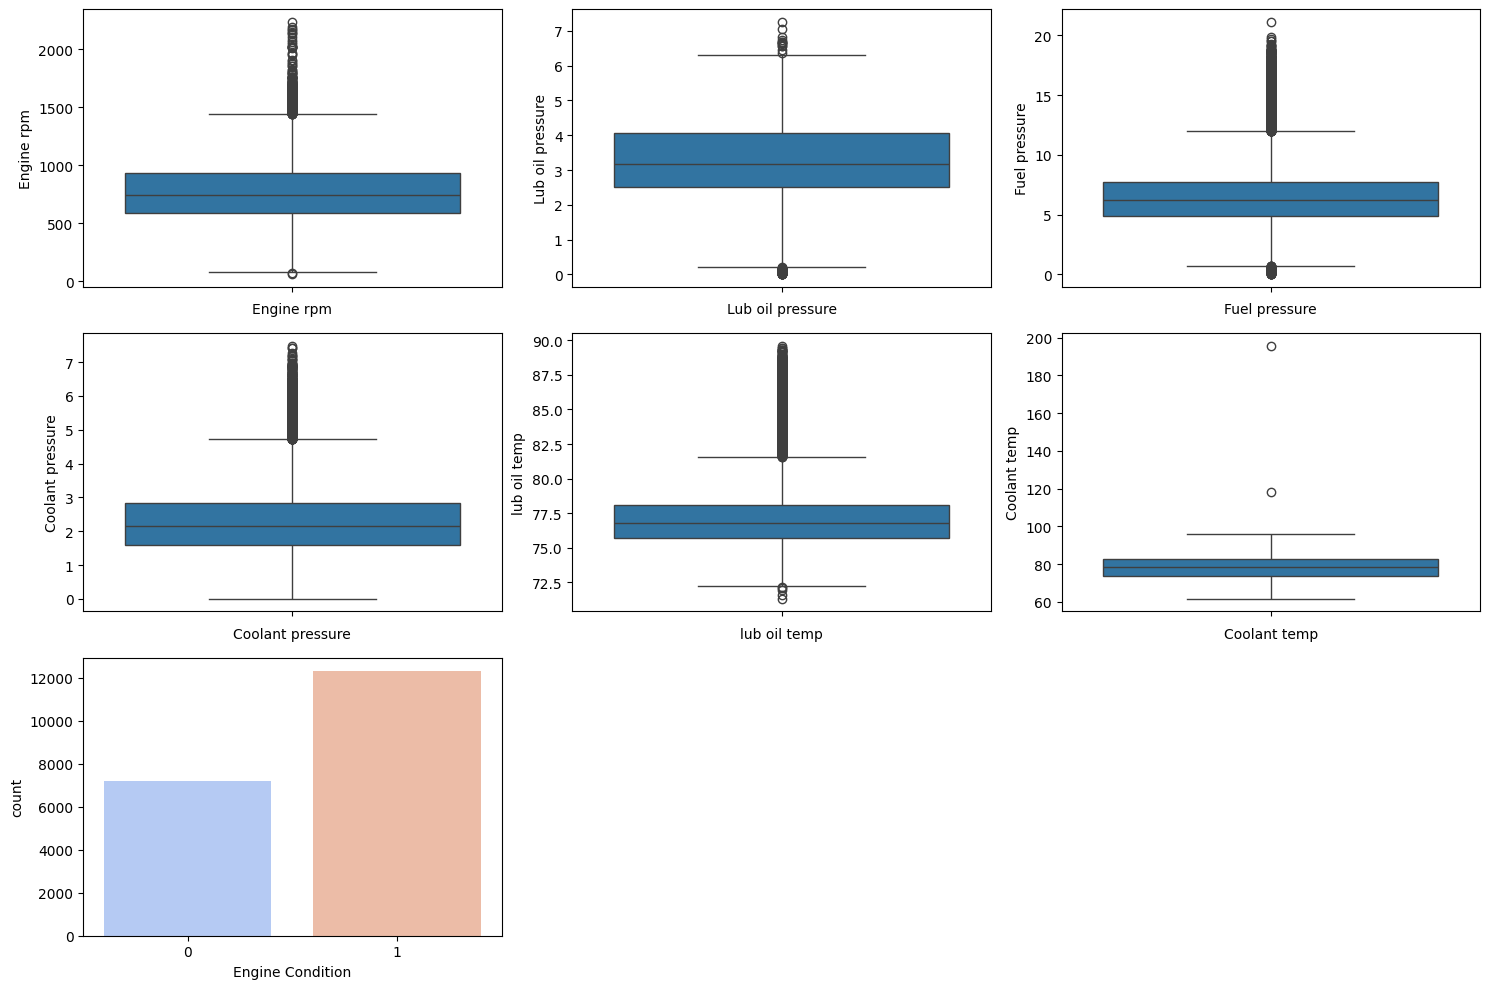

In [ ]:
fig, axs = plt.subplots(3, 3, figsize=(15, 10))       #creates 3x3 grid of subplots

# Creating boxplots for numerical columns
sns.boxplot(data['Engine rpm'], ax=axs[0, 0]).set(xlabel='Engine rpm')
sns.boxplot(data['Lub oil pressure'], ax=axs[0, 1]).set(xlabel='Lub oil pressure')
sns.boxplot(data['Fuel pressure'], ax=axs[0, 2]).set(xlabel='Fuel pressure')
sns.boxplot(data['Coolant pressure'], ax=axs[1, 0]).set(xlabel='Coolant pressure')
sns.boxplot(data['lub oil temp'], ax=axs[1, 1]).set(xlabel='lub oil temp')
sns.boxplot(data['Coolant temp'], ax=axs[1, 2]).set(xlabel='Coolant temp')
sns.countplot(x='Engine Condition', data=data, ax=axs[2, 0], palette='coolwarm').set(xlabel='Engine Condition')

# Hiding the last two empty subplots
axs[2, 1].axis('off')
axs[2, 2].axis('off')

# Adjusting the layout so that graphs dont overlay each other
plt.tight_layout()

In [ ]:
data.columns

Index(['Engine rpm', 'Lub oil pressure', 'Fuel pressure', 'Coolant pressure',
       'lub oil temp', 'Coolant temp', 'Engine Condition'],
      dtype='object')

In [ ]:
len(data)

19535

In [ ]:
# outlier treatment for Engine rpm

Q1 = data['Engine rpm'].quantile(0.25)
Q3 = data['Engine rpm'].quantile(0.75)
IQR = Q3 - Q1
data = data[(data['Engine rpm'] >= Q1 - 1.5*IQR) & (data['Engine rpm'] <= Q3 + 1.5*IQR)]
print(Q3,Q1)

934.0 593.0


In [ ]:
len(data)

19071

In [ ]:
# outlier treatment for Lub oil pressure

Q1 = data['Lub oil pressure'].quantile(0.25)
Q3 = data['Lub oil pressure'].quantile(0.75)
IQR = Q3 - Q1
data = data[(data['Lub oil pressure'] >= Q1 - 1.5*IQR) & (data['Lub oil pressure'] <= Q3 + 1.5*IQR)]
print(Q3,Q1)

4.054674228 2.5181868439999997


In [ ]:
len(data)

19008

In [ ]:
# outlier treatment for Fuel pressure

Q1 = data['Fuel pressure'].quantile(0.25)
Q3 = data['Fuel pressure'].quantile(0.75)
IQR = Q3 - Q1
data = data[(data['Fuel pressure'] >= Q1 - 1.5*IQR) & (data['Fuel pressure'] <= Q3 + 1.5*IQR)]
print(Q3,Q1)

7.74325486925 4.913276943


In [ ]:
len(data)

17904

In [ ]:
# outlier treatment for Coolant pressure

Q1 = data['Coolant pressure'].quantile(0.25)
Q3 = data['Coolant pressure'].quantile(0.75)
IQR = Q3 - Q1
data = data[(data['Coolant pressure'] >= Q1 - 1.5*IQR) & (data['Coolant pressure'] <= Q3 + 1.5*IQR)]
print(Q3,Q1)

2.8498879 1.60188677875


In [ ]:
len(data)

17183

In [ ]:
# outlier treatment for lub oil temp

Q1 = data['lub oil temp'].quantile(0.25)
Q3 = data['lub oil temp'].quantile(0.75)
IQR = Q3 - Q1
data = data[(data['lub oil temp'] >= Q1 - 1.5*IQR) & (data['lub oil temp'] <= Q3 + 1.5*IQR)]
print(Q3,Q1)

78.05548877999999 75.723003365


In [ ]:
len(data)

14886

In [11]:
# outlier treatment for Coolant temp

Q1 = data['Coolant temp'].quantile(0.25)
Q3 = data['Coolant temp'].quantile(0.75)
IQR = Q3 - Q1
data = data[(data['Coolant temp'] >= Q1 - 1.5*IQR) & (data['Coolant temp'] <= Q3 + 1.5*IQR)]
print(Q3,Q1)

82.915411335 73.89542093


In [ ]:
len(data)

14884

In [ ]:
#we only did outlier treatment for the Coolant temp since it got the best results

In [ ]:
data.columns

Index(['Engine rpm', 'Lub oil pressure', 'Fuel pressure', 'Coolant pressure',
       'lub oil temp', 'Coolant temp', 'Engine Condition'],
      dtype='object')

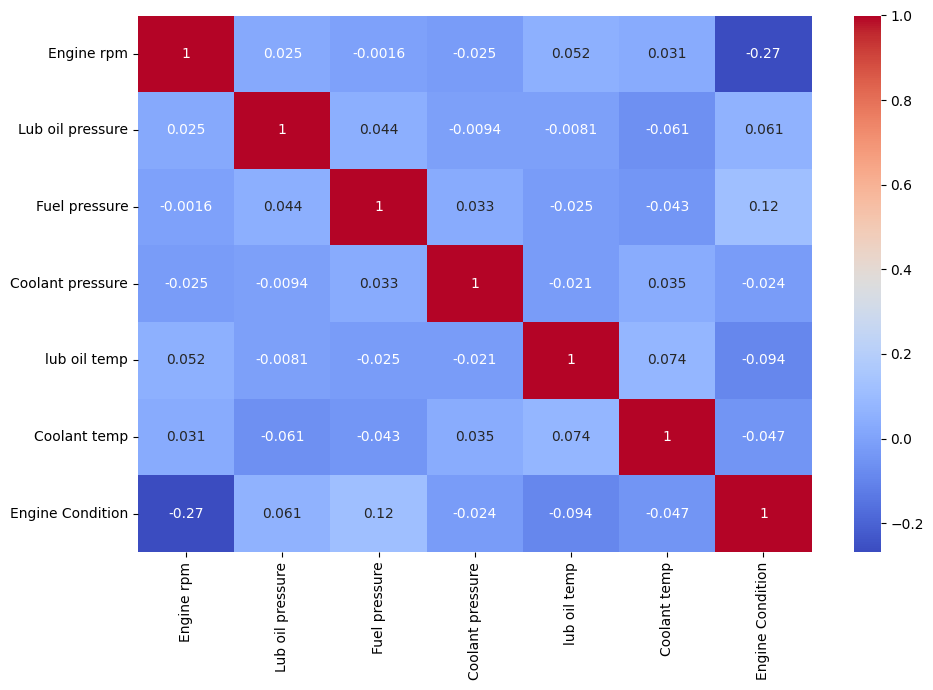

In [12]:
#the final visualisation to show what affects what.

plt.figure(figsize=(10, 7))
dataplot = sns.heatmap(data[['Engine rpm', 'Lub oil pressure', 'Fuel pressure', 'Coolant pressure', 'lub oil temp', 'Coolant temp', 'Engine Condition']].corr(), cmap="coolwarm", annot=True)
plt.tight_layout()

# Train test split and Data Scaling

In [13]:
def train_test_split_and_scale(data):
    y = data['Engine Condition']
    x = data.drop('Engine Condition',axis=1)
    features = list(x.columns)
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state = 0)
    scaler = MinMaxScaler()
    x_train = scaler.fit_transform(x_train)
    x_test = scaler.transform(x_test)
    return x_train, x_test, y_train, y_test,features


In [14]:
x_train, x_test, y_train, y_test,features = train_test_split_and_scale(data)

In [15]:
Counter(y_train)

Counter({1: 9823, 0: 5803})

In [16]:
def fit_and_evaluate_model(x_train, x_test, y_train, y_test,class_weight=None):
    lr = LogisticRegression(class_weight=class_weight)
    model = lr.fit(x_train, y_train)
    lr_predict = lr.predict(x_test)
    lr_conf_matrix = confusion_matrix(y_test, lr_predict)
    lr_acc_score = accuracy_score(y_test, lr_predict)
    print("confussion matrix")
    print(lr_conf_matrix)
    print("\n")
    print("Accuracy of Logistic Regression:",lr_acc_score*100,'\n')
    print(classification_report(y_test,lr_predict))
    return model

In [17]:
model = fit_and_evaluate_model(x_train, x_test, y_train, y_test)
print("odds ratio", np.exp(model.coef_))

confussion matrix
[[ 418  996]
 [ 314 2179]]


Accuracy of Logistic Regression: 66.47043767596621 

              precision    recall  f1-score   support

           0       0.57      0.30      0.39      1414
           1       0.69      0.87      0.77      2493

    accuracy                           0.66      3907
   macro avg       0.63      0.58      0.58      3907
weighted avg       0.64      0.66      0.63      3907

odds ratio [[0.00958387 2.69312557 7.90276654 0.58722619 0.42226513 0.76808447]]


In [18]:
Counter(y_train)

Counter({1: 9823, 0: 5803})

# Improve the model

In [19]:
# define class weights
weight = {0: 2.69, 1: 1.59}
model = fit_and_evaluate_model(x_train, x_test, y_train, y_test,class_weight=weight)


confussion matrix
[[ 867  547]
 [ 807 1686]]


Accuracy of Logistic Regression: 65.34425390325057 

              precision    recall  f1-score   support

           0       0.52      0.61      0.56      1414
           1       0.76      0.68      0.71      2493

    accuracy                           0.65      3907
   macro avg       0.64      0.64      0.64      3907
weighted avg       0.67      0.65      0.66      3907



In [20]:
results = pd.DataFrame(model.predict_proba(x_test))
results.columns = ['class_0_proba','class_1_proba']
results['predicted_class'] = model.predict(x_test)
results

,class_0_proba,class_1_proba,predicted_class
0,0.475907,0.524093,1
1,0.273712,0.726288,1
2,0.609751,0.390249,0
3,0.380389,0.619611,1
4,0.563457,0.436543,0
...,...,...,...
3902,0.401783,0.598217,1
3903,0.543047,0.456953,0
3904,0.549273,0.450727,0
3905,0.665625,0.334375,0


In [ ]:
#save and reuse the model

In [21]:
import joblib  # 'pip install joblib' if you get "Package Not found Error"
joblib.dump(model , 'model_classifier.pkl')                 #the model is save as model_classifier.pkl

['model_classifier.pkl']

In [22]:
model_read = joblib.load('model_classifier.pkl')            #loades the model
model_read.predict(x_test)

array([1, 1, 0, ..., 0, 0, 1])

# Model interpretation

In [ ]:
# Feature importance
# Odds ratio well higher than 1: Increase in fetaure value increases probability of event hapenning

# A feature with an odds ratio near zero typically suggests that the associated predictor has
#a strong negative impact on the odds of the event occurring.

# Odds ratio near 1 indicates that feature may not be a strong predictor

In [23]:
odds_ratio = np.exp(model.coef_)[0]

for z in range(len(features)):
     print("Odds ratio for feature {} is {}".format(features[z], odds_ratio[z]))

Odds ratio for feature Engine rpm is 0.007565539754930926
Odds ratio for feature Lub oil pressure is 2.716785204069987
Odds ratio for feature Fuel pressure is 7.84228347621822
Odds ratio for feature Coolant pressure is 0.6016341058557662
Odds ratio for feature lub oil temp is 0.4141110094679258
Odds ratio for feature Coolant temp is 0.7567854989655156


In [ ]:
# Engine rpm has a strong negative impact
# Lub oil temp has a strong negative impact
# Coolant temp has a strong negative impact

# Coolant pressure may not be a strong predictor

# Lub oil pressure has a stong positive impact
# Fuel pressure has a strongest positive impact